# 2D CNN Training Smoke Test v0.1

This notebook is a **first end-to-end smoke test** for machine sound anomaly detection using exported 2D tensors.

It verifies:
- manifest loading and subset selection
- clip-level train/validation splitting
- data loading into `(2, 96, 64)` tensors
- forward pass, loss, backprop, and short training run
- basic final evaluation and a clear PASS/FAIL verdict

## 1. Configuration section

In [1]:
from pathlib import Path
from typing import Sequence
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    from sklearn.metrics import classification_report
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# -----------------------------
# Editable configuration values
# -----------------------------
output_root = Path("/home/mitch/development/raccoon-ball/training-data")

# You can provide either a single path (Path/str) or a list of paths.
window_manifest_path = [
    Path("/home/mitch/development/raccoon-ball/training-data/-6db-pump-normal/manifests/20260319_152022_windows.parquet"),
    Path("/home/mitch/development/raccoon-ball/training-data/-6db-pump-abnormal/manifests/20260319_155015_windows.parquet"),
]
clip_manifest_path = [
    Path("/home/mitch/development/raccoon-ball/training-data/-6db-pump-normal/manifests/20260319_152022_files.parquet"),
    Path("/home/mitch/development/raccoon-ball/training-data/-6db-pump-abnormal/manifests/20260319_155015_files.parquet"),
]

machine_filter = "pump"
max_normal_clips = 10
max_abnormal_clips = 10
batch_size = 16
num_epochs = 5
learning_rate = 1e-3
device = "cuda" if torch.cuda.is_available() else "cpu"

random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)

CHECKS = {
    "manifests loaded": False,
    "subset built": False,
    "clip-level split applied": False,
    "dataset loader works": False,
    "batch shapes are correct": False,
    "model forward pass works": False,
    "loss computed": False,
    "backprop works": False,
    "training completed": False,
    "no NaNs encountered": True,
}

NAN_DETECTED = False
TRAINING_EXCEPTION = None

print("Config loaded.")
print(f"device={device}, batch_size={batch_size}, num_epochs={num_epochs}, learning_rate={learning_rate}")

Config loaded.
device=cuda, batch_size=16, num_epochs=5, learning_rate=0.001


## 2. Manifest loading and filtering section

In [2]:
def _to_path_list(value):
    if isinstance(value, (str, Path)):
        raw = [value]
    elif isinstance(value, Sequence):
        raw = list(value)
    else:
        raise TypeError(f"Expected Path/str or a sequence of paths, got {type(value)}")

    out = []
    for v in raw:
        p = Path(v).expanduser()
        if not p.is_absolute():
            p = (Path.cwd() / p).resolve()
        out.append(p)
    return out


def _read_parquet_many(paths, kind_name):
    dfs = []
    for p in paths:
        if not p.exists():
            raise FileNotFoundError(f"{kind_name} manifest not found: {p}")
        try:
            df = pd.read_parquet(p)
        except Exception as exc:
            raise RuntimeError(
                f"Failed to read {kind_name} parquet at {p}. Ensure pyarrow/fastparquet is installed."
            ) from exc
        if df.empty:
            print(f"Warning: {kind_name} manifest is empty: {p}")
        df = df.copy()
        df["_manifest_path"] = str(p)
        dfs.append(df)

    if not dfs:
        raise RuntimeError(f"No {kind_name} manifests provided.")
    return pd.concat(dfs, ignore_index=True)


def _pick_first_column(df, candidates, required=True, purpose=""):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find required column for {purpose}. Tried: {candidates}. Available: {list(df.columns)}")
    return None


def _normalize_path_str(x):
    return str(x).replace("\\", "/")


def _resolve_npz_path(path_value, output_root_path):
    p = Path(str(path_value)).expanduser()
    candidates = []

    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.append((Path.cwd() / p).resolve())
        candidates.append((output_root_path / p).resolve())
        candidates.append((output_root_path / "tensors" / p).resolve())

    for c in candidates:
        if c.exists():
            return c
    return candidates[0]


def _label_from_text(text):
    t = str(text).lower()
    if ("abnormal" in t) or ("-ab-" in t) or re.search(r"(^|[-_/])ab($|[-_/])", t):
        return 1
    if ("normal" in t) or ("-nm-" in t) or re.search(r"(^|[-_/])nm($|[-_/])", t):
        return 0
    return None


def _infer_label(row, explicit_label_col, text_cols):
    if explicit_label_col is not None:
        v = row.get(explicit_label_col)
        if pd.notna(v):
            token = str(v).strip().lower()
            if token in {"normal", "nm", "0", "false", "non_anomalous", "non-anomalous"}:
                return 0
            if token in {"abnormal", "ab", "1", "true", "anomalous", "anomaly"}:
                return 1

    for c in text_cols:
        if c in row and pd.notna(row[c]):
            parsed = _label_from_text(row[c])
            if parsed is not None:
                return parsed
    return None


def _infer_machine(row, explicit_machine_col, text_cols):
    if explicit_machine_col is not None:
        v = row.get(explicit_machine_col)
        if pd.notna(v):
            return str(v).strip().lower()

    text = " ".join(str(row[c]) for c in text_cols if c in row and pd.notna(row[c])).lower()
    for token in ["pump", "fan", "slider", "valve"]:
        if re.search(rf"(^|[-_/]){token}($|[-_/])", text) or token in text:
            return token
    return None


def _split_clip_ids(ids, train_fraction=0.8, seed=42):
    ids = list(dict.fromkeys([str(x) for x in ids]))
    if len(ids) == 0:
        return [], []

    rng = np.random.default_rng(seed)
    rng.shuffle(ids)

    if len(ids) == 1:
        return ids, []

    n_train = int(round(len(ids) * train_fraction))
    n_train = max(1, min(n_train, len(ids) - 1))
    return ids[:n_train], ids[n_train:]


window_manifest_paths = _to_path_list(window_manifest_path)
clip_manifest_paths = _to_path_list(clip_manifest_path)

window_df = _read_parquet_many(window_manifest_paths, "window")
clip_df = _read_parquet_many(clip_manifest_paths, "clip")

# Keep successful clips only when status is available.
if "status" in clip_df.columns:
    clip_df = clip_df[clip_df["status"].isin(["exported", "skipped_existing"])].copy()

if window_df.empty or clip_df.empty:
    raise RuntimeError("Window or clip manifest is empty after loading/filtering.")

CHECKS["manifests loaded"] = True

clip_npz_col = _pick_first_column(
    clip_df,
    ["tensor_npz_path", "npz_path", "tensor_path", "npz", "path"],
    required=True,
    purpose="clip npz path",
)
window_npz_col = _pick_first_column(
    window_df,
    ["tensor_npz_path", "npz_path", "tensor_path", "npz", "path"],
    required=True,
    purpose="window npz path",
)
tensor_index_col = _pick_first_column(
    window_df,
    ["tensor_index", "window_index"],
    required=True,
    purpose="window tensor index",
)

clip_df = clip_df.copy()
window_df = window_df.copy()

clip_df["_npz_path"] = clip_df[clip_npz_col].map(lambda x: str(_resolve_npz_path(x, output_root)))
window_df["_npz_path"] = window_df[window_npz_col].map(lambda x: str(_resolve_npz_path(x, output_root)))
clip_df["_npz_norm"] = clip_df["_npz_path"].map(_normalize_path_str)
window_df["_npz_norm"] = window_df["_npz_path"].map(_normalize_path_str)

clip_id_col = _pick_first_column(
    clip_df,
    ["clip_id", "relative_source_path", "source_file", "tensor_npz_path"],
    required=False,
    purpose="clip identity",
)
if clip_id_col is None:
    clip_df["_clip_id"] = clip_df["_npz_path"].map(lambda p: Path(p).stem)
else:
    clip_df["_clip_id"] = clip_df[clip_id_col].astype(str)

label_col = _pick_first_column(
    clip_df,
    ["label", "class_label", "class", "target", "condition", "anomaly_label"],
    required=False,
    purpose="label",
)
machine_col = _pick_first_column(
    clip_df,
    ["machine", "machine_type", "machine_name"],
    required=False,
    purpose="machine",
)

text_cols_for_inference = [
    c for c in ["source_file", "relative_source_path", "tensor_npz_path", "_npz_path"] if c in clip_df.columns
]
clip_df["label"] = clip_df.apply(lambda r: _infer_label(r, label_col, text_cols_for_inference), axis=1)
clip_df["machine"] = clip_df.apply(lambda r: _infer_machine(r, machine_col, text_cols_for_inference), axis=1)

missing_label_mask = clip_df["label"].isna()
if missing_label_mask.any():
    examples = clip_df.loc[missing_label_mask, text_cols_for_inference].head(5)
    msg = (
        "Could not infer normal/abnormal label for some clips. "
        "Please add a label column or use path naming containing normal/abnormal or -nm-/-ab-."
    )
    raise RuntimeError(msg + " Example rows: " + examples.to_string(index=False))

clip_df["label"] = clip_df["label"].astype(int)

if machine_filter:
    mf = str(machine_filter).strip().lower()
    clip_df = clip_df[clip_df["machine"].fillna("").str.contains(mf, regex=False)].copy()

normal_clips_df = clip_df[clip_df["label"] == 0].drop_duplicates("_npz_norm").sort_values("_clip_id").head(max_normal_clips)
abnormal_clips_df = clip_df[clip_df["label"] == 1].drop_duplicates("_npz_norm").sort_values("_clip_id").head(max_abnormal_clips)
selected_clips_df = pd.concat([normal_clips_df, abnormal_clips_df], ignore_index=True)

if normal_clips_df.empty or abnormal_clips_df.empty:
    raise RuntimeError(
        "Need at least one normal and one abnormal clip after filtering. "
        "Adjust manifests, machine_filter, or clip limits."
    )

CHECKS["subset built"] = True

selected_lookup = selected_clips_df[["_npz_norm", "_npz_path", "_clip_id", "label"]].drop_duplicates("_npz_norm")
window_df["tensor_index"] = window_df[tensor_index_col].astype(int)
selected_windows_df = window_df.merge(selected_lookup, on="_npz_norm", how="inner")

if selected_windows_df.empty:
    # Fallback: filename-based join if absolute paths differ.
    window_df["_npz_name"] = window_df["_npz_path"].map(lambda p: Path(p).name)
    selected_lookup = selected_lookup.copy()
    selected_lookup["_npz_name"] = selected_lookup["_npz_path"].map(lambda p: Path(p).name)
    selected_windows_df = window_df.merge(selected_lookup, on="_npz_name", how="inner")

if selected_windows_df.empty:
    raise RuntimeError("Selected subset produced zero window rows. Check manifest alignment.")

selected_windows_df = selected_windows_df.rename(
    columns={
        "_clip_id": "clip_id",
        "_npz_path_y": "npz_path",
        "_npz_path_x": "window_npz_path",
        "label": "label",
    }
)

if "npz_path" not in selected_windows_df.columns:
    if "_npz_path" in selected_windows_df.columns:
        selected_windows_df["npz_path"] = selected_windows_df["_npz_path"]
    elif "window_npz_path" in selected_windows_df.columns:
        selected_windows_df["npz_path"] = selected_windows_df["window_npz_path"]
    else:
        raise RuntimeError("Unable to resolve npz_path column in selected windows.")

train_clip_ids = []
val_clip_ids = []
for label_value in [0, 1]:
    class_clip_ids = selected_clips_df.loc[selected_clips_df["label"] == label_value, "_clip_id"].astype(str).tolist()
    tr_ids, va_ids = _split_clip_ids(class_clip_ids, train_fraction=0.8, seed=random_seed + label_value)
    train_clip_ids.extend(tr_ids)
    val_clip_ids.extend(va_ids)

# Guardrail: ensure both splits are non-empty.
if len(train_clip_ids) == 0 or len(val_clip_ids) == 0:
    raise RuntimeError(
        "Clip split produced an empty train or validation split. "
        "Increase clip counts so each class has at least 2 clips."
    )

if set(train_clip_ids).intersection(set(val_clip_ids)):
    raise RuntimeError("Clip leakage detected: at least one clip appears in both train and validation.")

train_windows_df = selected_windows_df[selected_windows_df["clip_id"].astype(str).isin(train_clip_ids)].copy()
val_windows_df = selected_windows_df[selected_windows_df["clip_id"].astype(str).isin(val_clip_ids)].copy()

if train_windows_df.empty or val_windows_df.empty:
    raise RuntimeError("Train or validation window set is empty after clip-level split.")

CHECKS["clip-level split applied"] = True

print(f"Loaded window rows: {len(window_df):,}")
print(f"Loaded clip rows: {len(clip_df):,}")
print(f"Selected normal clips: {len(normal_clips_df)}")
print(f"Selected abnormal clips: {len(abnormal_clips_df)}")
print("Train clip IDs:")
for cid in sorted(train_clip_ids):
    print(f"  - {cid}")
print("Validation clip IDs:")
for cid in sorted(val_clip_ids):
    print(f"  - {cid}")

Loaded window rows: 75,690
Loaded clip rows: 4,205
Selected normal clips: 10
Selected abnormal clips: 10
Train clip IDs:
  - -6-pump-00-ab-0001.wav
  - -6-pump-00-ab-0002.wav
  - -6-pump-00-ab-0004.wav
  - -6-pump-00-ab-0005.wav
  - -6-pump-00-ab-0006.wav
  - -6-pump-00-ab-0007.wav
  - -6-pump-00-ab-0008.wav
  - -6-pump-00-ab-0009.wav
  - -6-pump-00-nm-0000.wav
  - -6-pump-00-nm-0002.wav
  - -6-pump-00-nm-0003.wav
  - -6-pump-00-nm-0004.wav
  - -6-pump-00-nm-0005.wav
  - -6-pump-00-nm-0006.wav
  - -6-pump-00-nm-0007.wav
  - -6-pump-00-nm-0009.wav
Validation clip IDs:
  - -6-pump-00-ab-0000.wav
  - -6-pump-00-ab-0003.wav
  - -6-pump-00-nm-0001.wav
  - -6-pump-00-nm-0008.wav


## 3. Dataset summary section

In [3]:
def _class_balance_str(df):
    vc = df["label"].value_counts().sort_index()
    total = int(vc.sum()) if len(vc) else 0
    n0 = int(vc.get(0, 0))
    n1 = int(vc.get(1, 0))
    if total == 0:
        return "normal=0 (0.00%), abnormal=0 (0.00%)"
    return (
        f"normal={n0} ({100.0*n0/total:.2f}%), "
        f"abnormal={n1} ({100.0*n1/total:.2f}%)"
    )

train_clip_count = selected_clips_df[selected_clips_df["_clip_id"].astype(str).isin(train_clip_ids)]["_clip_id"].nunique()
val_clip_count = selected_clips_df[selected_clips_df["_clip_id"].astype(str).isin(val_clip_ids)]["_clip_id"].nunique()

print("Machine type selected:", machine_filter)
print("Number of normal clips selected:", len(normal_clips_df))
print("Number of abnormal clips selected:", len(abnormal_clips_df))
print("Total train clips:", int(train_clip_count))
print("Total validation clips:", int(val_clip_count))
print("Total train windows:", len(train_windows_df))
print("Total validation windows:", len(val_windows_df))
print("Class balance in train:", _class_balance_str(train_windows_df))
print("Class balance in validation:", _class_balance_str(val_windows_df))

Machine type selected: pump
Number of normal clips selected: 10
Number of abnormal clips selected: 10
Total train clips: 16
Total validation clips: 4
Total train windows: 288
Total validation windows: 72
Class balance in train: normal=144 (50.00%), abnormal=144 (50.00%)
Class balance in validation: normal=36 (50.00%), abnormal=36 (50.00%)


## 4. Dataset / loader implementation section

In [4]:
class TwoChannelWindowDataset(Dataset):
    def __init__(self, rows_df: pd.DataFrame):
        required_cols = {"npz_path", "tensor_index", "label", "clip_id"}
        missing = sorted(required_cols - set(rows_df.columns))
        if missing:
            raise ValueError(f"Dataset rows are missing required columns: {missing}")

        self.rows = rows_df[["npz_path", "tensor_index", "label", "clip_id"]].reset_index(drop=True).copy()

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        npz_path = Path(str(row["npz_path"]))
        tensor_index = int(row["tensor_index"])
        label = int(row["label"])

        if label not in (0, 1):
            raise ValueError(f"Invalid label at idx={idx}: {label}. Expected 0 (normal) or 1 (abnormal).")
        if not npz_path.exists():
            raise FileNotFoundError(f"NPZ not found at idx={idx}: {npz_path}")

        with np.load(npz_path, allow_pickle=False) as npz:
            if "normalized_window" not in npz.files:
                raise KeyError(f"Missing key 'normalized_window' in {npz_path}")
            if "active_mask" not in npz.files:
                raise KeyError(f"Missing key 'active_mask' in {npz_path}")

            normalized_all = npz["normalized_window"]
            active_all = npz["active_mask"]

            if tensor_index < 0 or tensor_index >= normalized_all.shape[0]:
                raise IndexError(
                    f"tensor_index out of bounds for {npz_path}: index={tensor_index}, N={normalized_all.shape[0]}"
                )

            normalized_window = normalized_all[tensor_index]
            active_mask = active_all[tensor_index]

        if normalized_window.shape != (96, 64):
            raise ValueError(
                f"normalized_window shape mismatch at idx={idx}: got {normalized_window.shape}, expected (96, 64)"
            )
        if active_mask.shape != (96, 64):
            raise ValueError(
                f"active_mask shape mismatch at idx={idx}: got {active_mask.shape}, expected (96, 64)"
            )

        x = np.stack(
            [
                normalized_window.astype(np.float32, copy=False),
                active_mask.astype(np.float32, copy=False),
            ],
            axis=0,
        )

        if x.shape != (2, 96, 64):
            raise ValueError(f"stacked tensor shape mismatch at idx={idx}: got {x.shape}, expected (2, 96, 64)")
        if x.dtype != np.float32:
            raise TypeError(f"stacked tensor dtype mismatch at idx={idx}: got {x.dtype}, expected float32")

        x_tensor = torch.from_numpy(x)
        y_tensor = torch.tensor(label, dtype=torch.long)

        return x_tensor, y_tensor


train_dataset = TwoChannelWindowDataset(train_windows_df)
val_dataset = TwoChannelWindowDataset(val_windows_df)

# Quick loader proof-of-life on a single item.
sample_x, sample_y = train_dataset[0]
print("Single sample input shape:", tuple(sample_x.shape))
print("Single sample input dtype:", sample_x.dtype)
print("Single sample label:", int(sample_y))

CHECKS["dataset loader works"] = (
    tuple(sample_x.shape) == (2, 96, 64)
    and sample_x.dtype == torch.float32
    and int(sample_y) in (0, 1)
)

Single sample input shape: (2, 96, 64)
Single sample input dtype: torch.float32
Single sample label: 0


## 5. Batch sanity-check section

In [5]:
pin_memory = str(device).startswith("cuda") and torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

batch_x, batch_y = next(iter(train_loader))

print("batch input shape:", tuple(batch_x.shape))
print("batch dtype:", batch_x.dtype)
print("batch device:", batch_x.device)
print("batch labels shape:", tuple(batch_y.shape))
print("unique labels in batch:", torch.unique(batch_y).tolist())
print("channel 0 min/max:", float(batch_x[:, 0].min()), float(batch_x[:, 0].max()))
print("channel 1 min/max:", float(batch_x[:, 1].min()), float(batch_x[:, 1].max()))

CHECKS["batch shapes are correct"] = (
    batch_x.ndim == 4
    and tuple(batch_x.shape[1:]) == (2, 96, 64)
    and batch_x.dtype == torch.float32
    and batch_y.ndim == 1
)

batch input shape: (16, 2, 96, 64)
batch dtype: torch.float32
batch device: cpu
batch labels shape: (16,)
unique labels in batch: [0, 1]
channel 0 min/max: 0.0 1.0
channel 1 min/max: 0.0 1.0


## 6. Model definition section

In [6]:
class Baseline2DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model = Baseline2DCNN()
with torch.no_grad():
    test_logits = model(batch_x[: min(4, len(batch_x))])

print("Model output logits shape:", tuple(test_logits.shape))
CHECKS["model forward pass works"] = (test_logits.ndim == 2 and test_logits.shape[1] == 2)

Model output logits shape: (4, 2)


## 7. Training setup section

In [7]:
requested_device = torch.device(device)
if requested_device.type == "cuda" and not torch.cuda.is_available():
    print("CUDA requested but unavailable. Falling back to CPU.")
    requested_device = torch.device("cpu")

runtime_device = requested_device
model = model.to(runtime_device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

param_count = sum(p.numel() for p in model.parameters())
print("Model parameter count:", param_count)
print("Device used:", runtime_device)

Model parameter count: 24082
Device used: cuda


## 8. Training loop section

In [8]:
def _check_no_nan(name, tensor):
    global NAN_DETECTED
    if torch.isnan(tensor).any():
        NAN_DETECTED = True
        raise RuntimeError(f"NaN detected in {name}")


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(1, num_epochs + 1):
    try:
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for x, y in train_loader:
            x = x.to(runtime_device, non_blocking=True)
            y = y.to(runtime_device, non_blocking=True)

            _check_no_nan("train inputs", x)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            _check_no_nan("train logits", logits)

            loss = criterion(logits, y)
            if torch.isnan(loss):
                NAN_DETECTED = True
                raise RuntimeError("NaN detected in train loss")

            CHECKS["loss computed"] = True

            loss.backward()
            CHECKS["backprop works"] = True
            optimizer.step()

            train_loss_sum += float(loss.item()) * x.size(0)
            preds = torch.argmax(logits, dim=1)
            train_correct += int((preds == y).sum().item())
            train_total += int(y.size(0))

        train_loss = train_loss_sum / max(1, train_total)
        train_acc = train_correct / max(1, train_total)

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(runtime_device, non_blocking=True)
                y = y.to(runtime_device, non_blocking=True)

                _check_no_nan("validation inputs", x)

                logits = model(x)
                _check_no_nan("validation logits", logits)

                loss = criterion(logits, y)
                if torch.isnan(loss):
                    NAN_DETECTED = True
                    raise RuntimeError("NaN detected in validation loss")

                val_loss_sum += float(loss.item()) * x.size(0)
                preds = torch.argmax(logits, dim=1)
                val_correct += int((preds == y).sum().item())
                val_total += int(y.size(0))

        val_loss = val_loss_sum / max(1, val_total)
        val_acc = val_correct / max(1, val_total)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    except Exception as exc:
        TRAINING_EXCEPTION = exc
        print(f"Training stopped with error: {type(exc).__name__}: {exc}")
        break


if TRAINING_EXCEPTION is None and len(history["train_loss"]) == num_epochs:
    CHECKS["training completed"] = True

CHECKS["no NaNs encountered"] = not NAN_DETECTED

Epoch 01/5 | train_loss=0.6950, train_acc=0.4792 | val_loss=0.6923, val_acc=0.5000
Epoch 02/5 | train_loss=0.6938, train_acc=0.4653 | val_loss=0.6926, val_acc=0.5000
Epoch 03/5 | train_loss=0.6940, train_acc=0.4688 | val_loss=0.6925, val_acc=0.5000
Epoch 04/5 | train_loss=0.6925, train_acc=0.4792 | val_loss=0.6917, val_acc=0.5000
Epoch 05/5 | train_loss=0.6928, train_acc=0.5174 | val_loss=0.6910, val_acc=0.5000


## 9. Final evaluation section

In [9]:
def _evaluate_loader(loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(runtime_device, non_blocking=True)
            y = y.to(runtime_device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    return np.asarray(y_true, dtype=np.int64), np.asarray(y_pred, dtype=np.int64)


def _confusion_matrix_binary(y_true, y_pred):
    cm = np.zeros((2, 2), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        if t in (0, 1) and p in (0, 1):
            cm[t, p] += 1
    return cm


if history["train_acc"]:
    final_train_acc = history["train_acc"][-1]
    final_val_acc = history["val_acc"][-1]
else:
    final_train_acc = float("nan")
    final_val_acc = float("nan")

print("Final train accuracy:", final_train_acc)
print("Final validation accuracy:", final_val_acc)

val_y_true, val_y_pred = _evaluate_loader(val_loader)
cm = _confusion_matrix_binary(val_y_true, val_y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["true_normal", "true_abnormal"],
    columns=["pred_normal", "pred_abnormal"],
)
print("Confusion matrix (validation):")
display(cm_df)

if SKLEARN_AVAILABLE:
    print("Classification report (validation):")
    print(classification_report(
        val_y_true,
        val_y_pred,
        labels=[0, 1],
        target_names=["normal", "abnormal"],
        digits=4,
        zero_division=0,
    ))
else:
    print("sklearn.metrics not available; skipping classification report.")

Final train accuracy: 0.5173611111111112
Final validation accuracy: 0.5
Confusion matrix (validation):


,pred_normal,pred_abnormal
true_normal,36,0
true_abnormal,36,0


Classification report (validation):
              precision    recall  f1-score   support

      normal     0.5000    1.0000    0.6667        36
    abnormal     0.0000    0.0000    0.0000        36

    accuracy                         0.5000        72
   macro avg     0.2500    0.5000    0.3333        72
weighted avg     0.2500    0.5000    0.3333        72



## 10. Visualization section

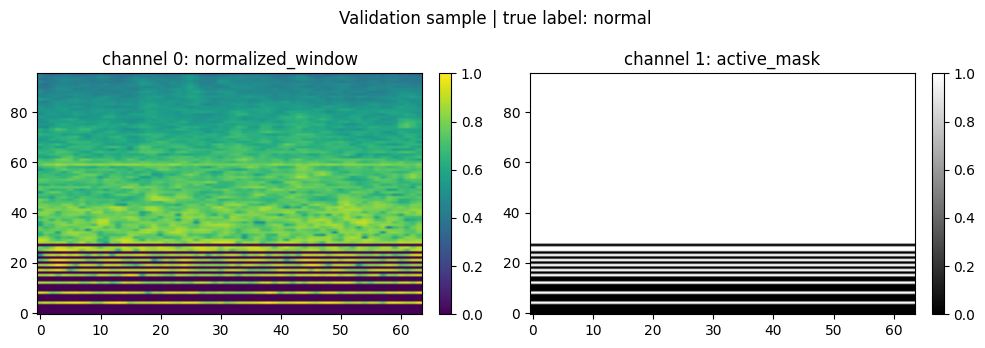

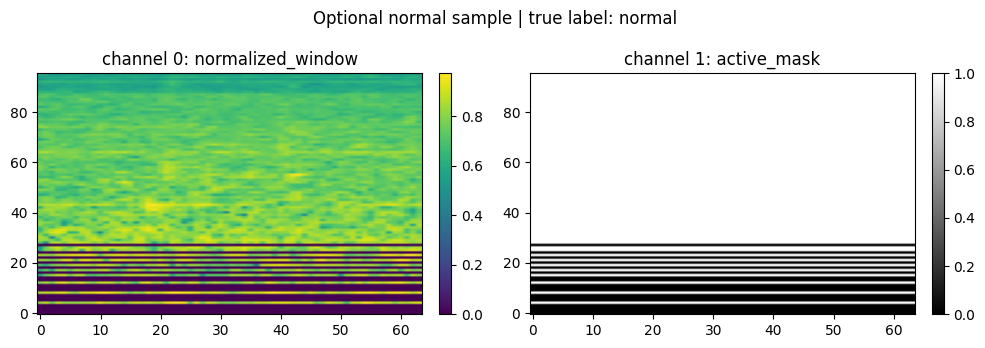

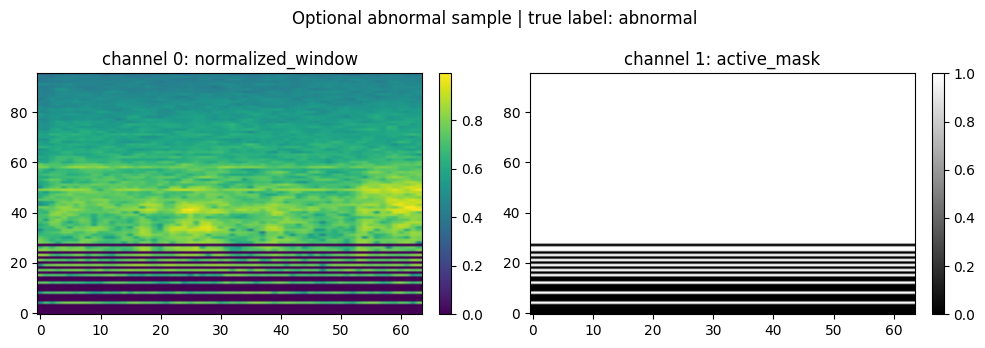

In [10]:
label_names = {0: "normal", 1: "abnormal"}


def _plot_dataset_index(dataset, idx, title_prefix):
    x, y = dataset[idx]
    y_int = int(y)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    im0 = axes[0].imshow(x[0].numpy(), aspect="auto", origin="lower", cmap="viridis")
    axes[0].set_title("channel 0: normalized_window")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(x[1].numpy(), aspect="auto", origin="lower", cmap="gray")
    axes[1].set_title("channel 1: active_mask")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    fig.suptitle(f"{title_prefix} | true label: {label_names.get(y_int, y_int)}")
    fig.tight_layout()
    plt.show()


if len(val_dataset) > 0:
    _plot_dataset_index(val_dataset, 0, "Validation sample")
else:
    print("Validation dataset is empty; cannot plot sample.")

# Optional: show one normal and one abnormal sample if present.
combined_rows = pd.concat([train_windows_df, val_windows_df], ignore_index=True)
for lbl, lbl_name in [(0, "normal"), (1, "abnormal")]:
    idxs = combined_rows.index[combined_rows["label"] == lbl].tolist()
    if idxs:
        temp_ds = TwoChannelWindowDataset(combined_rows.iloc[[idxs[0]]])
        _plot_dataset_index(temp_ds, 0, f"Optional {lbl_name} sample")

## 11. Final verdict section

In [11]:
print("PASS / READY")
pass_items = [k for k, v in CHECKS.items() if v]
if pass_items:
    for item in pass_items:
        print(f"- {item}")
else:
    print("- none")

print("")
print("FAIL / PATCH REQUIRED")
fail_items = [k for k, v in CHECKS.items() if not v]
if fail_items:
    for item in fail_items:
        print(f"- {item}")
else:
    print("- none")

if TRAINING_EXCEPTION is not None:
    print(f"- training_exception: {type(TRAINING_EXCEPTION).__name__}: {TRAINING_EXCEPTION}")

final_verdict = "READY_FOR_LARGER_RUN" if not fail_items else "PATCH_REQUIRED"
print("")
print("FINAL_VERDICT:", final_verdict)
print(final_verdict)

PASS / READY
- manifests loaded
- subset built
- clip-level split applied
- dataset loader works
- batch shapes are correct
- model forward pass works
- loss computed
- backprop works
- training completed
- no NaNs encountered

FAIL / PATCH REQUIRED
- none

FINAL_VERDICT: READY_FOR_LARGER_RUN
READY_FOR_LARGER_RUN
